# Tutorial 01 -- Getting Started with a Minimal Dispersive Model

Build the smallest useful transmon-storage model, inspect its dressed energies, and verify how the qubit transition changes with cavity photon number in the rotating frame.

**Prerequisites.** Comfort with Python and the idea of a dispersive qubit-cavity Hamiltonian is enough.


## 1. Goal

We will construct a minimal two-mode dispersive model, define a rotating frame, inspect the first few dressed energy levels, and compare the `|g,n> <-> |e,n>` transition for `n = 0` and `n = 3`.


## 2. Physical Background

In the dispersive regime the qubit and cavity are not exchanging excitations resonantly, but the qubit transition still depends on cavity occupancy. In `cqed_sim` the runtime two-mode Hamiltonian includes a conditional term proportional to `chi * n_c * n_q`, so negative `chi` shifts the qubit transition downward with photon number.


## 3. Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    Pulse,
    SequenceCompiler,
    SimulationConfig,
    compute_energy_spectrum,
    manifold_transition_frequency,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_mhz,
    final_expectation,
    ns,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 4. Simulation Parameters


In [2]:
omega_c_hz = 5.15e9
omega_q_hz = 6.35e9
alpha_hz = -220.0e6
chi_hz = -2.4e6
kerr_hz = -3.0e3
n_cav = 8
n_tr = 2


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(omega_c_hz / 1.0e9),
    omega_q=GHz(omega_q_hz / 1.0e9),
    alpha=MHz(alpha_hz / 1.0e6),
    chi=MHz(chi_hz / 1.0e6),
    kerr=MHz(kerr_hz / 1.0e6),
    n_cav=n_cav,
    n_tr=n_tr,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)

transition_n0 = manifold_transition_frequency(model, 0, frame=frame)
transition_n3 = manifold_transition_frequency(model, 3, frame=frame)
lab_spectrum = compute_energy_spectrum(model, frame=FrameSpec(), levels=10)

print("Subsystem dimensions:", model.subsystem_dims)
print("Qubit-first basis state |e,2> dims:", model.basis_state(1, 2).dims)
print(f"omega_ge(n=0) / 2pi = {angular_to_mhz(transition_n0):+.3f} MHz in the chosen frame")
print(f"omega_ge(n=3) / 2pi = {angular_to_mhz(transition_n3):+.3f} MHz in the chosen frame")
print(f"difference / 2pi = {angular_to_mhz(transition_n3 - transition_n0):+.3f} MHz")


Subsystem dimensions: (2, 8)
Qubit-first basis state |e,2> dims: [[2, 8], [1]]
omega_ge(n=0) / 2pi = +0.000 MHz in the chosen frame
omega_ge(n=3) / 2pi = -7.200 MHz in the chosen frame
difference / 2pi = -7.200 MHz


## 6. Pulse / Sequence Construction


In [4]:
idle_duration = 80.0 * ns
compiled_idle = SequenceCompiler(dt=2.0 * ns).compile([], t_end=idle_duration)
initial_state = (model.basis_state(0, 0) + model.basis_state(1, 0)).unit()


## 7. Running the Simulation


In [5]:
matched_frame_result = simulate_sequence(
    model,
    compiled_idle,
    initial_state,
    {},
    config=SimulationConfig(frame=frame, store_states=True),
)
lab_frame_result = simulate_sequence(
    model,
    compiled_idle,
    initial_state,
    {},
    config=SimulationConfig(frame=FrameSpec(), store_states=True),
)

matched_pe = final_expectation(matched_frame_result, "P_e")
lab_pe = final_expectation(lab_frame_result, "P_e")
print(f"Final P_e in the matched rotating frame: {matched_pe:.3f}")
print(f"Final P_e in the lab frame: {lab_pe:.3f}")


Final P_e in the matched rotating frame: 0.500
Final P_e in the lab frame: 0.500


## 8. Visualizing the Results


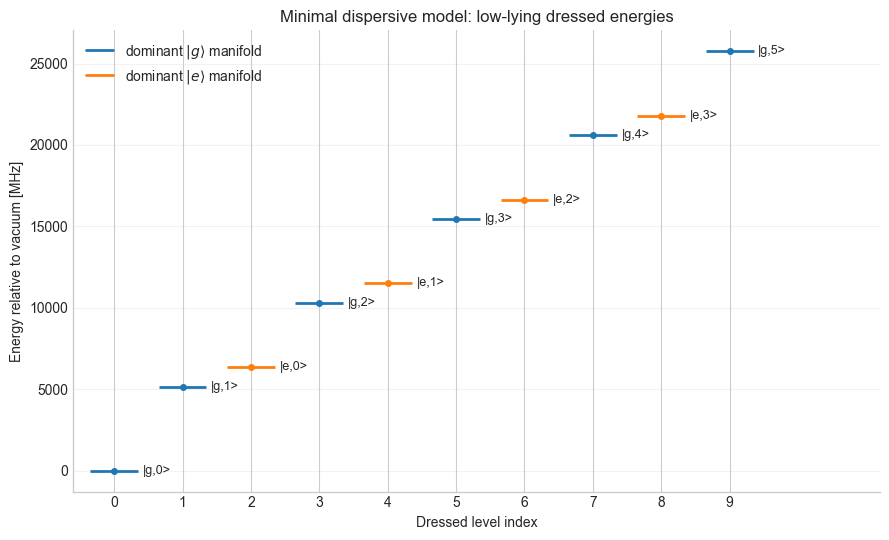

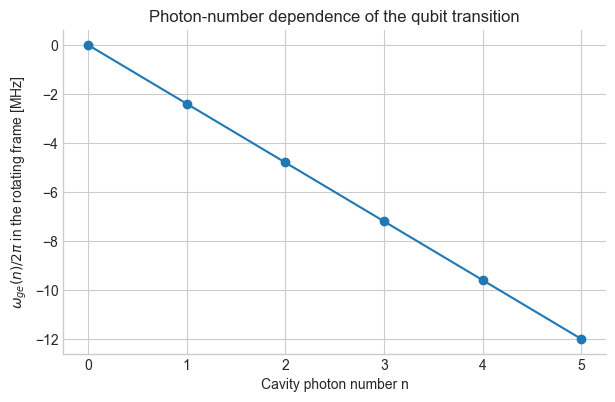

In [6]:
fig = plot_energy_levels(
    lab_spectrum,
    max_levels=10,
    energy_scale=1.0 / (2.0 * np.pi * 1.0e6),
    energy_unit_label="MHz",
    title="Minimal dispersive model: low-lying dressed energies",
)
plt.show()

n_values = np.arange(6)
transition_mhz = [angular_to_mhz(manifold_transition_frequency(model, int(n), frame=frame)) for n in n_values]
fig, ax = plt.subplots()
ax.plot(n_values, transition_mhz, "o-")
ax.set_xlabel("Cavity photon number n")
ax.set_ylabel(r"$\omega_{ge}(n) / 2\pi$ in the rotating frame [MHz]")
ax.set_title("Photon-number dependence of the qubit transition")
plt.show()


## 9. Physical Interpretation

The matched rotating frame removes the large bare cavity and qubit oscillations, so the remaining transition frequencies are the small residual detunings that matter for spectroscopy and pulse design. Because `chi` is negative here, the `n = 3` manifold sits below the `n = 0` manifold by roughly `3 * chi`.


## 10. Exercises / Next Steps

- Change `chi_hz` from negative to positive and re-run the transition-versus-`n` plot.
- Increase `n_tr` to `3` and compare the low-lying spectrum to see where transmon anharmonicity starts to matter.
- Continue to Tutorial 02 for a focused walkthrough of units, frames, and carrier-sign conventions.
